In [48]:
import numpy as np
import pandas as pd

from pathlib import Path
from cnn_connectome.rf_data import load_input_table, get_dog_params

import matplotlib.pyplot as plt
import matplotlib.colors as colors 
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.patches import Polygon

In [49]:
def fwhm_to_sigma(fwhm):
    return fwhm / (2 * np.sqrt(2 * np.log(2)))


def DoG_from_radius(r, sign, fwhm_c, fwhm_s=None, A_rel=None,  projected_1d=True,):
    """
    Radial Difference-of-Gaussians RF.

    Parameters
    ----------
    r : array-like
        Radial distance from RF center, in degrees.
        For 1D, r can just be x.
        For 2D, r = sqrt(x^2 + y^2).

    sign : float
        +1 for ON-like, -1 for OFF-like.

    fwhm_c : float
        Center FWHM in degrees.

    fwhm_s : float or NaN
        Surround FWHM in degrees. If NaN, no surround is used.

    A_rel : float or NaN
        Relative surround amplitude. If NaN, no surround is used.

    Returns
    -------
    rf : np.ndarray
        RF evaluated at radius r.
    """
    r = np.asarray(r, dtype=float)

    sigma_c = fwhm_to_sigma(fwhm_c)
    rf_c = np.exp(-(r**2) / (2 * sigma_c**2))

    if pd.isna(fwhm_s) or pd.isna(A_rel):
        rf_s = 0.0
    else:
        sigma_s = fwhm_to_sigma(fwhm_s)
        if projected_1d:
            A_eff = A_rel * (sigma_s / sigma_c)
        else:
            A_eff = A_rel
        rf_s = A_eff * np.exp(-(r**2) / (2 * sigma_s**2))

    return sign * (rf_c - rf_s)

def DoG_1D(x, sign, fwhm_c, fwhm_s=None, A_rel=None,projected_1d=True):
    """
    1D cross-section of radial DoG.
    """
    return DoG_from_radius(
        r=x,
        sign=sign,
        fwhm_c=fwhm_c,
        fwhm_s=fwhm_s,
        A_rel=A_rel,
        projected_1d=projected_1d
    )
### TODO:
### Chekch math between cross section and projection. 
### Current code reproduces paper figures but I'm unsure if the Math is actually right
def DoG_2D(x_grid, y_grid, sign, fwhm_c, fwhm_s=None, A_rel=None, projected_1d=False):
    """
    2D radially symmetric DoG.
    """
    r = np.sqrt(x_grid**2 + y_grid**2)

    return DoG_from_radius(
        r=r,
        sign=sign,
        fwhm_c=fwhm_c,
        fwhm_s=fwhm_s,
        A_rel=A_rel,
        projected_1d=projected_1d
    )

In [50]:
from scipy.special import erf

def box_avg_1d(c, w, sigma):
    """Average of exp(-x^2/2sigma^2) over [c-w/2, c+w/2]."""
    s2 = sigma * np.sqrt(2)
    return (sigma * np.sqrt(np.pi / 2) / w) * (
        erf((c + w / 2) / s2) - erf((c - w / 2) / s2)
    )

def DoG_2D_boxavg(cx, cy, sign, fwhm_c, fwhm_s=None, A_rel=None,
                   box_size=None, projected_1d=False):
    sigma_c = fwhm_to_sigma(fwhm_c)
    center = box_avg_1d(cx, box_size, sigma_c) * box_avg_1d(cy, box_size, sigma_c)

    if pd.isna(fwhm_s) or pd.isna(A_rel):
        return sign * center

    sigma_s = fwhm_to_sigma(fwhm_s)
    A_eff = A_rel * (sigma_s / sigma_c) if projected_1d else A_rel
    surround = A_eff * box_avg_1d(cx, box_size, sigma_s) * box_avg_1d(cy, box_size, sigma_s)
    return sign * (center - surround)

In [51]:
### Data from: Drews et al 2018  10.1016/j.cub.2017.01.051 
### CT1 data pending
T4_inputs = load_input_table("T4").reindex()
T5_inputs = load_input_table("T5").reindex()

In [52]:

norm_linear = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
# x2 = np.linspace(-28, 28, 200)
# y2 = np.linspace(-28, 28, 200)
# x = np.linspace(-28, 28, 500)

# X, Y = np.meshgrid(x2, y2)
# norm_linear = colors.Normalize(vmin=-1, vmax=1)
# for ctype in T5_inputs["Celltype"].unique():
#     data = T5_inputs.query("Celltype == @ctype")
#     row = data.iloc[0]

#     rf_1d = DoG_1D(
#         x,
#         sign=row["Sign"],
#         fwhm_c=row["FWHMcen(deg)"],
#         fwhm_s=row["FWHMsur(deg)"],
#         A_rel=row["Asur/Acen"],
#     )

#     rf_2d = DoG_2D(
#         X, Y,
#         sign=row["Sign"],
#         fwhm_c=row["FWHMcen(deg)"],
#         fwhm_s=row["FWHMsur(deg)"],
#         A_rel=row["Asur/Acen"],
#     )


In [53]:
def hex_lattice_centers(xmin, xmax, ymin, ymax, spacing=5.0):
    """
    Generate hex lattice centers covering the rectangle.
    
    spacing = nearest-neighbor center-to-center distance (deg)
    """
    centers = []

    # triangular lattice basis
    dx = spacing
    dy = np.sqrt(3) * spacing / 2

    # extend a bit beyond bounds so the lattice covers the panel nicely
    j_min = int(np.floor((ymin - 2 * spacing) / dy))
    j_max = int(np.ceil((ymax + 2 * spacing) / dy))

    i_min = int(np.floor((xmin - 2 * spacing) / dx))
    i_max = int(np.ceil((xmax + 2 * spacing) / dx))

    for j in range(j_min, j_max + 1):
        y = j * dy
        x_offset = 0.5 * spacing if (j % 2) else 0.0

        for i in range(i_min, i_max + 1):
            x = i * spacing + x_offset

            if (xmin - spacing <= x <= xmax + spacing and
                ymin - spacing <= y <= ymax + spacing):
                centers.append((x, y))

    return np.array(centers)


def hexagon_vertices(cx, cy, radius):
    """
    Pointy-top hexagon centered at (cx, cy).
    radius = circumradius = side length
    """
    angles = np.deg2rad([90, 150, 210, 270, 330, 30])
    xs = cx + radius * np.cos(angles)
    ys = cy + radius * np.sin(angles)
    return np.column_stack([xs, ys])


def overlay_hex_lattice(
    ax,
    xmin,
    xmax,
    ymin,
    ymax,
    spacing=5.0,
    edgecolor="k",
    linewidth=0.6,
    alpha=0.6,
    show_centers=False,
):
    """
    Overlay a hexagonal sampling lattice on an axis.
    spacing = nearest-neighbor center spacing in degrees
    """
    centers = hex_lattice_centers(xmin, xmax, ymin, ymax, spacing=spacing)

    # For a tiling regular hex grid:
    hex_radius = spacing / np.sqrt(3)

    for cx, cy in centers:
        verts = hexagon_vertices(cx, cy, hex_radius)
        poly = Polygon(
            verts,
            closed=True,
            fill=False,
            edgecolor=edgecolor,
            linewidth=linewidth,
            alpha=alpha,
        )
        ax.add_patch(poly)

    if show_centers and len(centers) > 0:
        ax.scatter(centers[:, 0], centers[:, 1], s=6, c="k", alpha=0.6)

    return centers

In [54]:
def plot_hex_sampled_rf(
    ax,
    centers,
    values,
    spacing=5.0,
    cmap="bwr",
    norm=None,
    edgecolor="k",
    linewidth=0.4,
):
    """
    Plot one scalar RF value per hexagon.
    """
    hex_radius = spacing / np.sqrt(3)
    cmap_obj = plt.get_cmap(cmap)

    for (cx, cy), val in zip(centers, values):
        verts = hexagon_vertices(cx, cy, hex_radius)

        if norm is None:
            color = cmap_obj(val)
        else:
            color = cmap_obj(norm(val))

        poly = Polygon(
            verts,
            closed=True,
            facecolor=color,
            edgecolor=edgecolor,
            linewidth=linewidth,
        )
        ax.add_patch(poly)

    ax.set_aspect("equal")
    ax.autoscale_view()


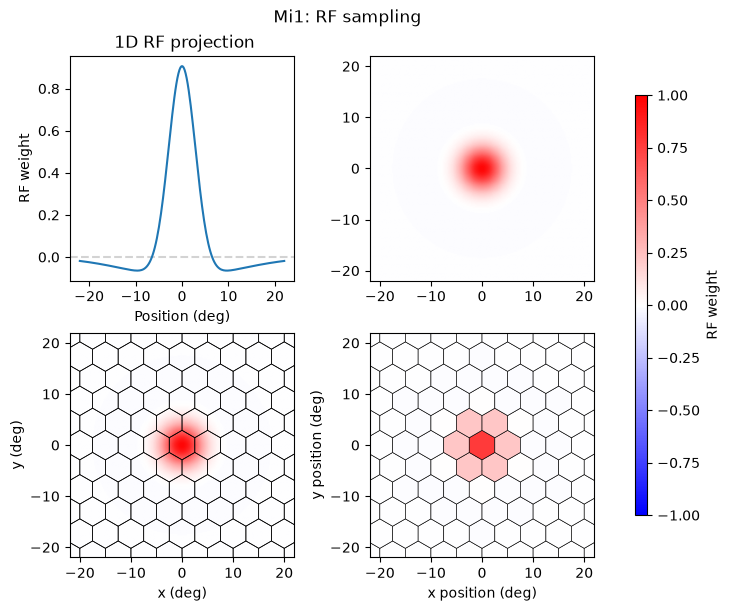

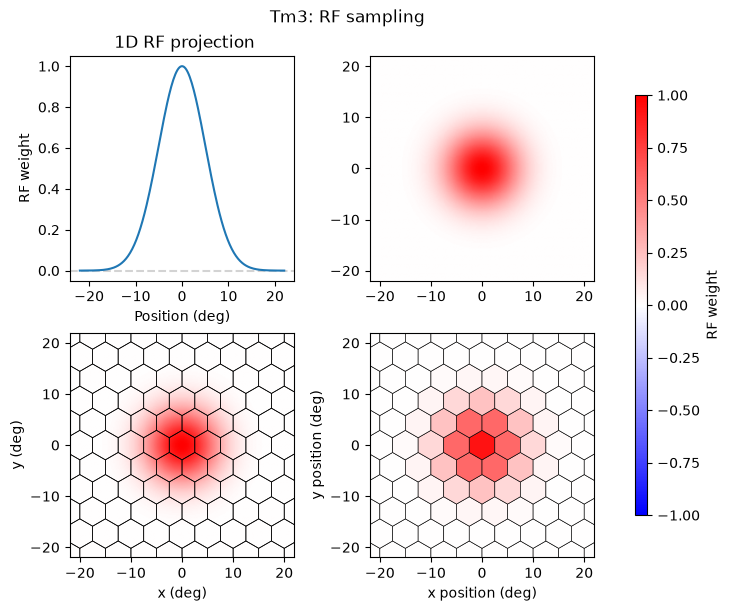

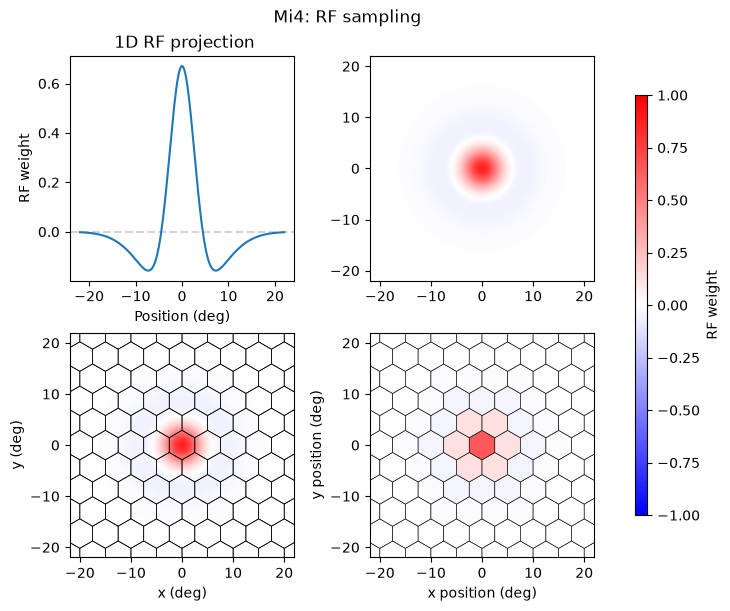

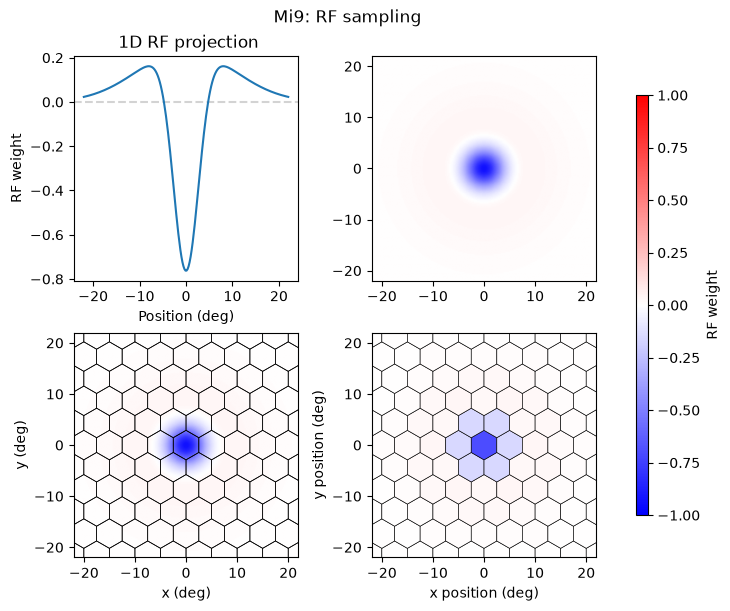

In [55]:

x2 = np.linspace(-22, 22, 200)
y2 = np.linspace(-22, 22, 200)

X, Y = np.meshgrid(x2, y2)
xmin, xmax = x2.min(), x2.max()
ymin, ymax =  y2.min(), y2.max()

hex_spacing_deg = 5.0
hex_spacing_deg = 5.0

for ctype in T4_inputs["Celltype"].unique():
    data = T4_inputs.query("Celltype == @ctype")
    row = data.iloc[0]

    rf_1d = DoG_1D(
        x2,
        sign=row["Sign"],
        fwhm_c=row["FWHMcen(deg)"],
        fwhm_s=row["FWHMsur(deg)"],
        A_rel=row["Asur/Acen"],
        projected_1d=True,
    )

    rf_2d = DoG_2D(
        X, Y,
        sign=row["Sign"],
        fwhm_c=row["FWHMcen(deg)"],
        fwhm_s=row["FWHMsur(deg)"],
        A_rel=row["Asur/Acen"],
        projected_1d=False,
    )

    ratio = (ymax - ymin) / (xmax - xmin)  # 48/56 ≈ 0.857, matches your imshow aspect="equal"

    fig, axs = plt.subplots(2, 2, figsize=(6, 6), layout="constrained")
    fig.suptitle(f"{ctype}: RF sampling", x=0.57)
    
    for ax in axs.flat:
        ax.set_box_aspect(ratio)
        
    axs[0,0].axhline(0, ls='--', c='lightgray')
    axs[0,0].plot(x2, rf_1d)
    axs[0,0].set_title(" 1D RF projection")
    axs[0,0].set_xlabel("Position (deg)")
    axs[0,0].set_ylabel("RF weight")

    _ = axs[0,1].imshow(
    rf_2d,
    extent=[x2.min(), x2.max(), y2.min(), y2.max()],
    origin="lower",
    aspect="equal",
    cmap="bwr",
    norm=norm_linear,
    )

    

    im = axs[1,0].imshow(
    rf_2d,
    extent=[x2.min(), x2.max(), y2.min(), y2.max()],
    origin="lower",
    aspect="equal",
    cmap="bwr",
    norm=norm_linear,
    )

    # overlay hex lattice: 5 deg nearest-neighbor spacing
    centers = overlay_hex_lattice(
        axs[1,0],
        xmin=x2.min(),
        xmax=x2.max(),
        ymin=y2.min(),
        ymax=y2.max(),
        spacing=5.0,
        edgecolor="k",
        linewidth=0.5,
        alpha=1.0,
        show_centers=False,
    )

    # evaluate RF at hex centers
    cx = centers[:, 0]
    cy = centers[:, 1]


    rf_hex =  DoG_2D_boxavg(
        cx[None, :],
        cy[None, :],
        sign=row["Sign"],
        fwhm_c=row["FWHMcen(deg)"],
        fwhm_s=row["FWHMsur(deg)"],
        A_rel=row["Asur/Acen"],
        box_size = hex_spacing_deg,
        projected_1d=False,
    ).ravel()

    # axs[1,0].set_title(f"{ctype}: 2D radial DoG + hex samples")
    axs[1,0].set_xlabel("x (deg)")
    axs[1,0].set_ylabel("y (deg)")
    
    plot_hex_sampled_rf(
        ax=axs[1,1],
        centers=centers,
        values=rf_hex,
        spacing=hex_spacing_deg,
        cmap="bwr",
        norm=norm_linear,
        edgecolor="k",
        linewidth=0.45,
    )

    axs[1,1].set_xlim(xmin, xmax)
    axs[1,1].set_ylim(ymin, ymax)
    # axs[1,1].set_title(f"{ctype}: hex-sampled 2D DoG")
    axs[1,1].set_xlabel("x position (deg)")
    axs[1,1].set_ylabel("y position (deg)")
    
    sm = plt.cm.ScalarMappable(cmap="bwr", norm=norm_linear)
    cbar_ax = fig.add_axes([1.05, 0.15, 0.02, 0.7])  # [left, bottom, width, height] in figure fraction
    cbar_ax.set_in_layout(False)  # tell constrained_layout to ignore this axes
    fig.colorbar(sm, cax=cbar_ax, label="RF weight")
